In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [ ]:
df=pd.read_csv("/content/heart.csv")

In [ ]:
print("First 10 rows are:")
df.head()

First 10 rows are:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
print("\n📌 Dataset shape:")
print(df.shape)

print("\n📌 Dataset info:")
print(df.info())

print("\n📌 Statistical summary:")
display(df.describe())

print("\n📌 Missing values:")
print(df.isnull().sum())


📌 Dataset shape:
(303, 14)

📌 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

📌 Statistical summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



📌 Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


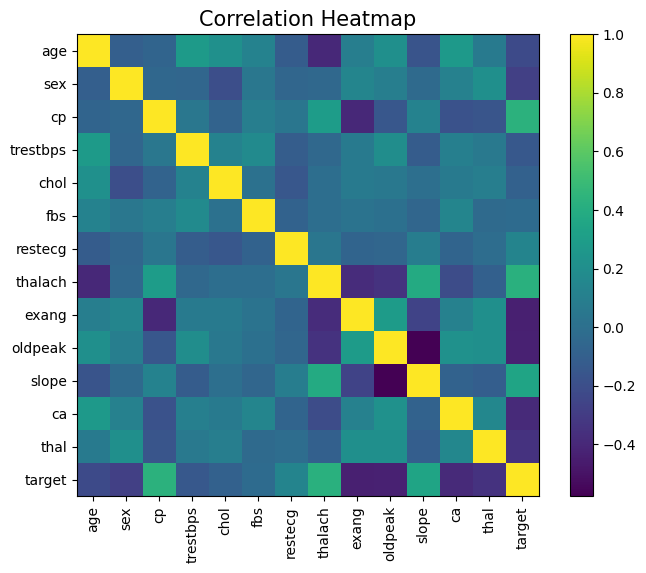

In [ ]:
plt.figure(figsize=(8, 6))
corr = df.corr()
plt.imshow(corr, interpolation='nearest')
plt.title("Correlation Heatmap", fontsize=15)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

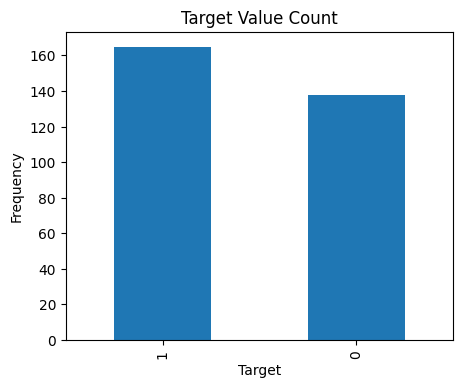

In [ ]:
plt.figure(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar')
plt.title("Target Value Count")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.show()

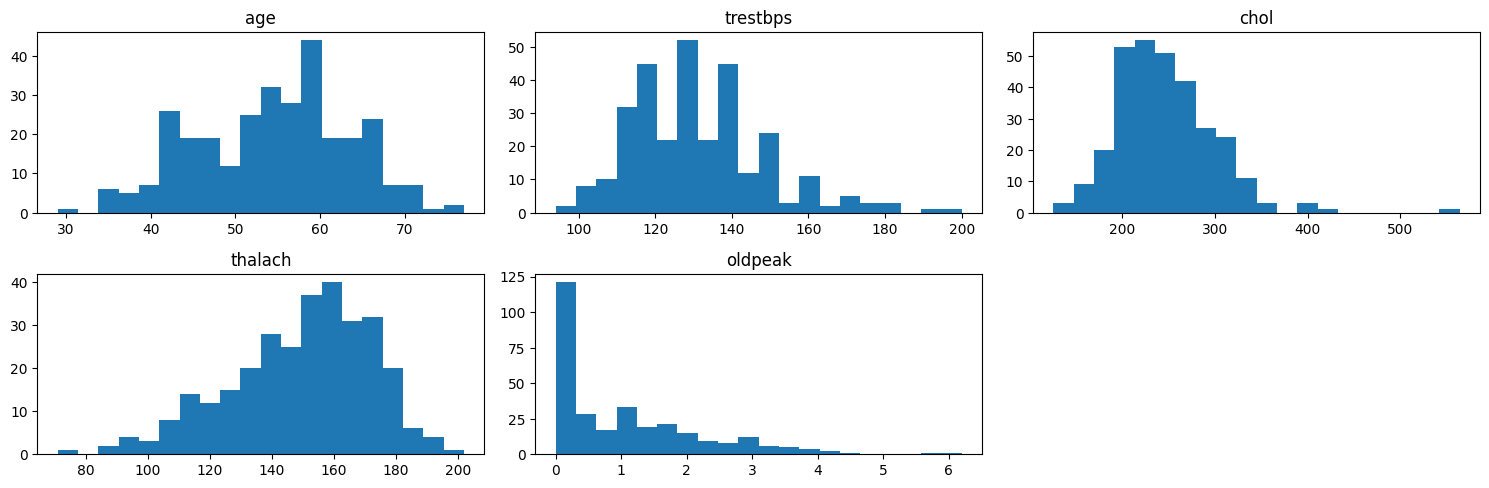

In [ ]:
num_cols = ['age','trestbps','chol','thalach','oldpeak']
plt.figure(figsize=(15, 12))

for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i+1)
    plt.hist(df[col], bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

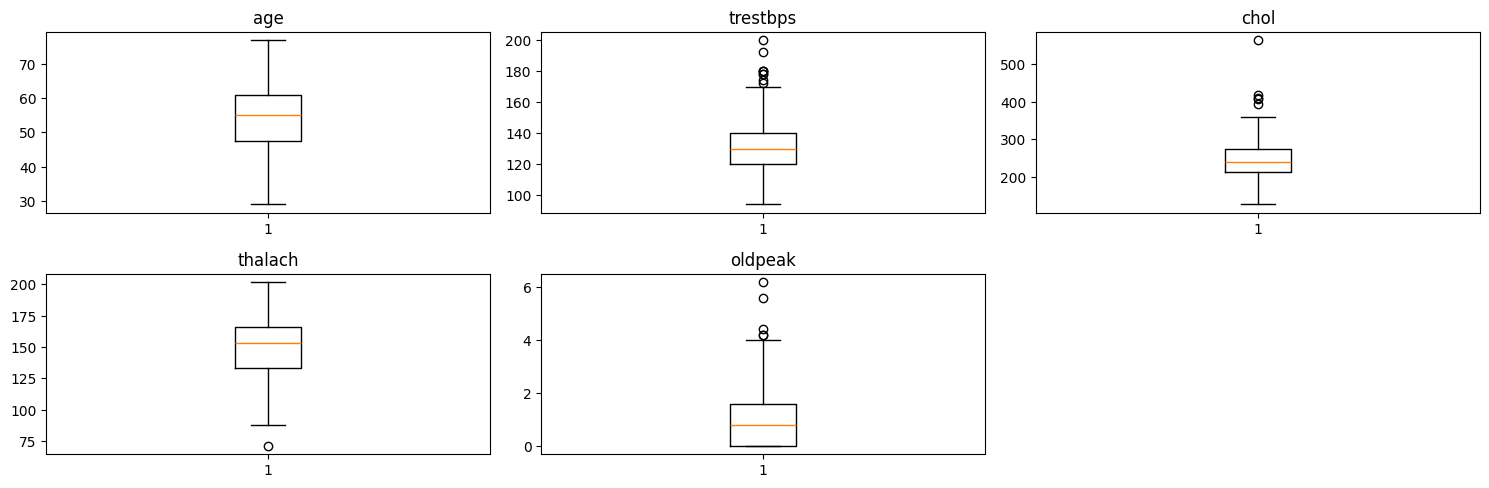

In [ ]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i+1)
    plt.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

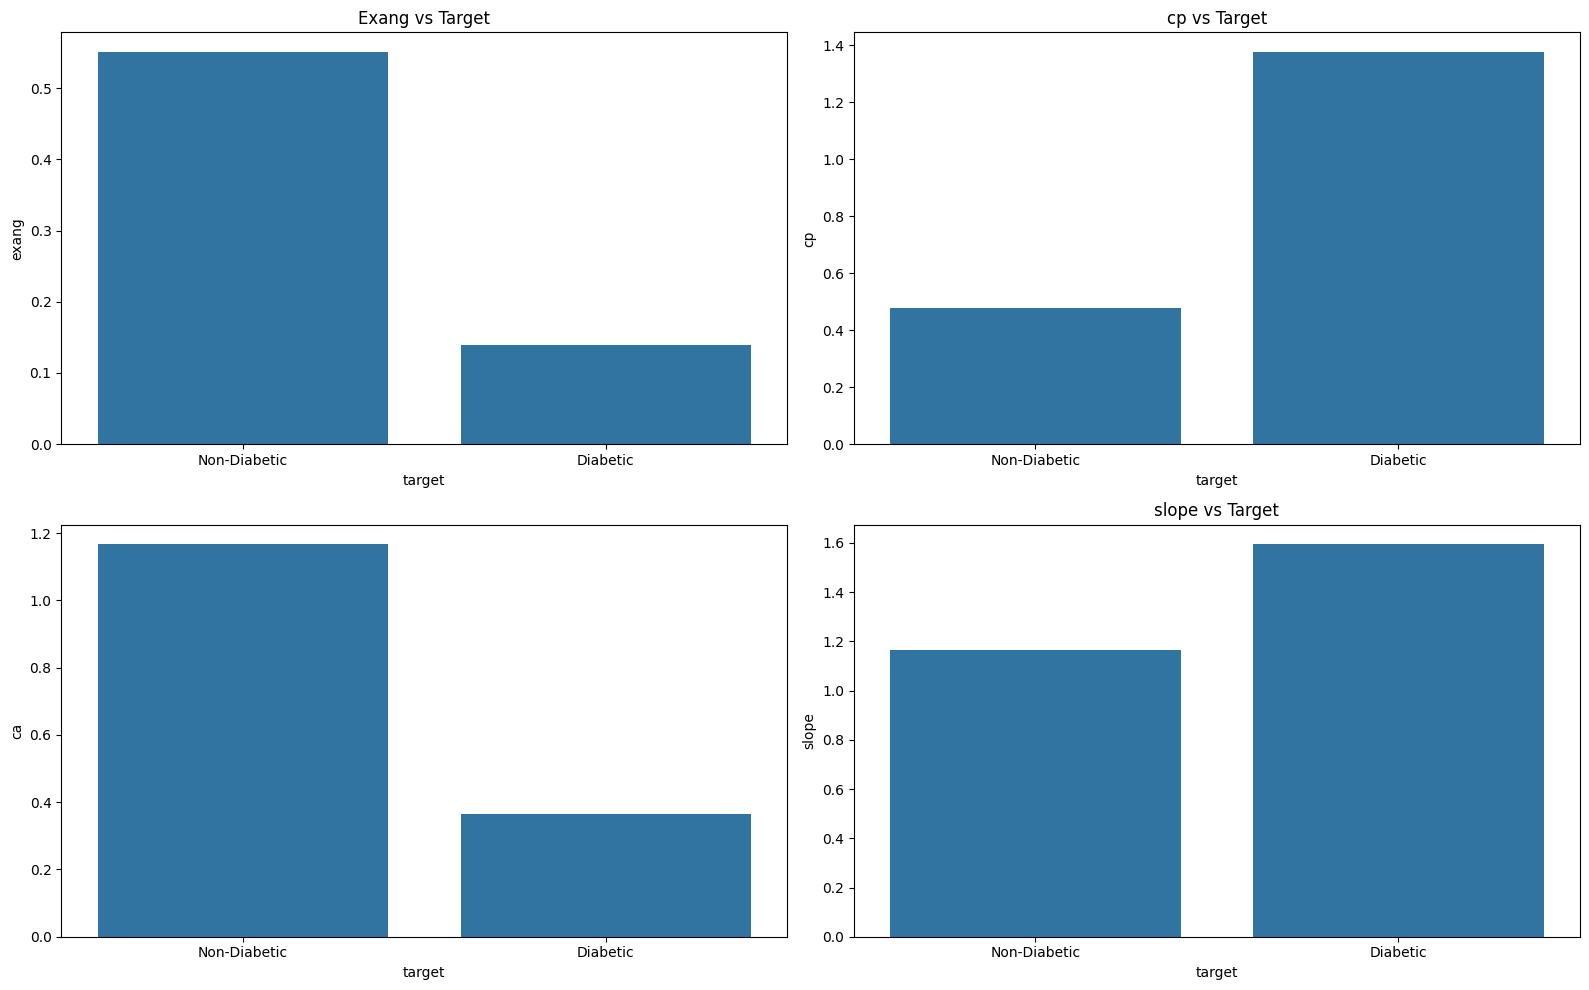

In [ ]:
grouped = df.groupby("target").mean()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Assign each subplot a variable
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

sns.barplot(x=grouped.index, y=grouped["exang"], ax=ax1)
ax1.set_title("Exang vs Target")

sns.barplot(x=grouped.index, y=grouped["cp"], ax=ax2)
ax2.set_title("cp vs Target")

sns.barplot(x=grouped.index, y=grouped["ca"], ax=ax3)
ax4.set_title("ca vs Target")

sns.barplot(x=grouped.index, y=grouped["slope"], ax=ax4)
ax4.set_title("slope vs Target")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])

plt.tight_layout()
plt.show()

In [ ]:
new_col=df.drop('target',axis=1)
scaler=StandardScaler()
standard=scaler.fit_transform(new_col)

In [ ]:
X=standard
y=df['target']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
print("Training Data Shape",X_train.shape)
print("Testing Data Shape",X_test.shape)

Training Data Shape (212, 13)
Testing Data Shape (91, 13)


In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr=lr.predict(X_test)

In [ ]:
print("Performance Metrics using Logistic Regression Model")
print('='*60)
print(f"Accuracy Score: {accuracy_score(y_test,y_pred_lr)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Performance Metrics using Logistic Regression Model
Accuracy Score: 81.32%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91


Confusion Matrix
[[32  9]
 [ 8 42]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [ ]:
y_pred_dt=dt.predict(X_test)

In [ ]:
print("Performance Metrics using Decision Tree Model")
print('='*60)
print(f"Accuracy Score: {accuracy_score(y_test,y_pred_dt)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Performance Metrics using Decision Tree Model
Accuracy Score: 72.53%

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.83      0.73        41
           1       0.82      0.64      0.72        50

    accuracy                           0.73        91
   macro avg       0.74      0.73      0.73        91
weighted avg       0.75      0.73      0.72        91


Confusion Matrix
[[34  7]
 [18 32]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_ensemble = RandomForestClassifier(n_estimators=100,max_depth=4,random_state=42)
model_ensemble.fit(X_train,y_train)

RandomForestClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred_rf=model_ensemble.predict(X_test)

In [ ]:
print("Performance Metrics using Random Forest Model")
print('='*60)
print(f"Accuracy Score: {accuracy_score(y_test,y_pred_rf)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Performance Metrics using Random Forest Model
Accuracy Score: 83.52%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        41
           1       0.83      0.88      0.85        50

    accuracy                           0.84        91
   macro avg       0.84      0.83      0.83        91
weighted avg       0.84      0.84      0.83        91


Confusion Matrix
[[32  9]
 [ 6 44]]


<Axes: >

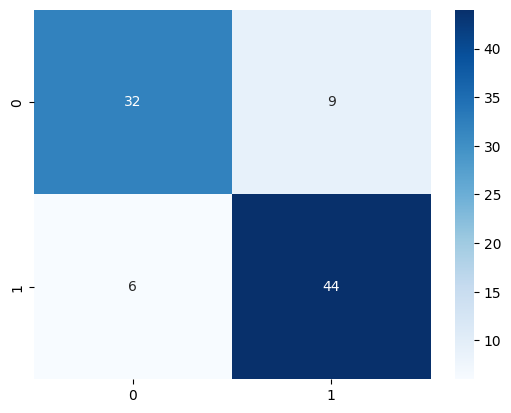

In [ ]:
cm = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

In [ ]:
from xgboost import XGBClassifier
model_boost= XGBClassifier()
model_boost.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb=model_boost.predict(X_test)

In [ ]:
print("Performance Metrics using Random Forest Model")
print('='*60)
print(f"Accuracy Score: {accuracy_score(y_test,y_pred_xgb)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

Performance Metrics using Random Forest Model
Accuracy Score: 81.32%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91


Confusion Matrix
[[32  9]
 [ 8 42]]


In [ ]:
import joblib

joblib.dump(scaler, "heart_scaler.joblib")
joblib.dump(model_ensemble, "heart.joblib")

['heart.joblib']